In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os

if 'google.colab' in sys.modules:
    REPO_NAME = "study-deep-learning"
    REPO_URL = f"https://github.com/miyayudai/{REPO_NAME}.git"
    TARGET_DIR = f"/content/{REPO_NAME}"
    CH_DIR = f"{TARGET_DIR}/11"

    # 1. リポジトリのダウンロード (未ダウンロード時のみ)
    if not os.path.exists(TARGET_DIR):
        print("📦 リポジトリをダウンロード中...")
        res = os.system(f"git clone {REPO_URL} {TARGET_DIR} 2>&1")
        
        # Private リポジトリ等で認証が必要な場合の自動救済
        if res != 0 or not os.path.exists(TARGET_DIR):
            token = None
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                pass
            
            if not token:
                import getpass
                print("🔒 リポジトリが非公開(Private)の場合、GitHub Personal Access Token (PAT) が必要です。")
                print("※公開(Public)リポジトリの場合はそのまま Enter を押してください。")
                token = getpass.getpass("GitHub Token (空欄可): ").strip()
            
            if token:
                auth_url = f"https://{token}@github.com/miyayudai/{REPO_NAME}.git"
                os.system(f"git clone {auth_url} {TARGET_DIR}")

    # 2. 依存パッケージとローカルモジュールのインストール
    print("⚙️ 環境セットアップ中...")
    if os.path.exists(TARGET_DIR):
        if TARGET_DIR not in sys.path:
            sys.path.insert(0, TARGET_DIR)
        req_path = os.path.join(TARGET_DIR, "requirements.txt")
        if os.path.exists(req_path):
            get_ipython().system(f"pip install -q -r {req_path}")
            get_ipython().system(f"pip install -q -e {TARGET_DIR}")
        if os.path.exists(CH_DIR):
            get_ipython().run_line_magic("cd", CH_DIR)
        else:
            get_ipython().run_line_magic("cd", TARGET_DIR)
        print("✅ 準備完了！このまま下のセルを実行できます。")
    else:
        print("⚠️ リポジトリのクローンがスキップされたため、必須パッケージを個別インストールします...")
        get_ipython().system("pip install -q pandas scikit-learn seaborn pillow")
        print("✅ パッケージインストール完了。")

# 第11章 構造化分布 (Structured Distributions)
## 11.2 条件付き独立性 (Conditional Independence)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第11章「構造化分布」第11.2節「条件付き独立性 (Conditional Independence)」の全7小節（11.2.1 〜 11.2.7）の完全な理論解説、数学的定式化（式 11.22 〜 式 11.41）、教科書図版（Figure 11.14 〜 11.26 全13枚）の完全再現、共通モジュール実装、および数値検証を提供します。

---

### 目次
1. **環境設定と共通モジュールのインポート**
2. **11.2.1 3つの代表的な3ノードグラフ (Three Example Graphs)**
   - **テール・トゥ・テール (Tail-to-Tail, 図 11.14, 11.15)**: $a \leftarrow c \to b$。未観測時は従属、観測時は独立 $a \perp b \mid c$
   - **ヘッド・トゥ・テール (Head-to-Tail, 図 11.16, 11.17)**: $a \to c \to b$。未観測時は従属、観測時は独立 $a \perp b \mid c$
   - **ヘッド・トゥ・ヘッド / コライダー (Head-to-Head / Collider, 図 11.18, 11.19)**: $a \to c \leftarrow b$。未観測時は独立 $a \perp b \mid \emptyset$、観測時は従属 $a \not\perp b \mid c$
3. **11.2.2 説明のつきあい (Explaining Away, 図 11.20, 式 11.32 〜 11.35)**
   - コライダーノードにおける直感的に逆説的な統計現象
   - 車の燃料系モデル：バッテリー $B$、燃料タンク $F$、燃料計 $G$
   - 燃料計空 ($G=0$) 観測時のガス欠確率：$p(F=0 \mid G=0) \approx 0.257$
   - バッテリー上がり ($B=0$) が追加観測されたとき：$p(F=0 \mid G=0, B=0) \approx 0.111$ に激減する理由
4. **11.2.3 D分離 (D-Separation, 図 11.21, 式 11.36)**
   - 有向グラフにおける大域的条件付き独立性の完全判定判定法
   - パスが「遮断（Blocked）」されるための2つの基準
   - i.i.d. データと重みパラメータの事後予測独立性：$\hat{t} \perp t_n \mid \mathbf{w}$
5. **11.2.4 ナイーブベイズ (Naive Bayes, 図 11.22, 11.23, 式 11.37 〜 11.41)**
   - クラス条件付き独立性仮定：$p(\mathbf{x} \mid C_k) = \prod_{l=1}^L p(x^{(l)} \mid C_k)$
   - 図 11.22: ナイーブベイズ分類器のグラフィカルモデル
   - 図 11.23: 2次元空間における因数分解されたクラス条件付き分布と、因数分解されない非対角な周辺混合密度 $p(\mathbf{x})$
6. **11.2.5 生成モデルと因果性 (Generative Models, 図 11.24)**
   - 順方向因果生成過程（Causal Process）：クラス、位置、スケール $\to$ 画像ピクセル
   - 識別モデルによる直接逆問題解法との対比
7. **11.2.6 マルコフブランケット (Markov Blanket, 図 11.25)**
   - ノード $x_i$ をグラフの残りすべてから完全に条件付き独立にする最小ノード集合
   - 親ノード群 (Parents) $\cup$ 子ノード群 (Children) $\cup$ 共通親ノード群 (Co-parents)
8. **11.2.7 分布のフィルタとしてのグラフ (Graphs as Filters, 図 11.26)**
   - 全確率分布の空間 $\mathcal{P}$、グラフ $G$ の因数分解を満たす分布族 $\mathcal{DF}$、および不忠実な分布 $\mathcal{UI}$
9. **数値検証・アルゴリズム検証セル**
10. **まとめと次節 11.3（系列モデル）への展開**


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# リポジトリルートをパスに追加
repo_root = Path.cwd().parent if Path.cwd().name == "11" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.graphical_models import DirectedGraph
from common.conditional_independence import (
    CarFuelSystem,
    check_d_separation,
    get_markov_blanket,
    generate_figure_11_14,
    generate_figure_11_15,
    generate_figure_11_16,
    generate_figure_11_17,
    generate_figure_11_18,
    generate_figure_11_19,
    generate_figure_11_20,
    generate_figure_11_21,
    generate_figure_11_22,
    generate_figure_11_23,
    generate_figure_11_24,
    generate_figure_11_25,
    generate_figure_11_26,
)

print("Setup completed successfully. Common modules for Section 11.2 imported.")


Setup completed successfully. Common modules for Section 11.2 imported.


---
## 11.2.1 3つの代表的な3ノードグラフ (Three Example Graphs)

条件付き独立性 $A \perp B \mid C$ とは、$C$ の値が与えられたとき、$A$ の条件付き確率分布が $B$ の値に依存しない（$p(A \mid B, C) = p(A \mid C)$、または同値として $p(A, B \mid C) = p(A \mid C) p(B \mid C)$）ことを意味します。

有向グラフィカルモデルにおけるすべての条件付き独立性は、以下の3つの基本的な3ノード結合パターンの組み合わせとして理解できます：

### 1. テール・トゥ・テール (Tail-to-Tail, 図 11.14 & 11.15)
結合分布：$p(a, b, c) = p(a \mid c) p(b \mid c) p(c)$
- **未観測時（図 11.14）**: $c$ について周辺化すると、$p(a, b) = \sum_c p(a \mid c) p(b \mid c) p(c)$ となり、一般に因数分解されないため**従属**（$a \not\perp b \mid \emptyset$）。
- **$c$ 観測時（図 11.15）**: $p(a, b \mid c) = \frac{p(a, b, c)}{p(c)} = p(a \mid c) p(b \mid c)$。したがって $c$ を条件付けると**独立**（$a \perp b \mid c$）。ノード $c$ はパスを「遮断（Block）」します。

### 2. ヘッド・トゥ・テール (Head-to-Tail, 図 11.16 & 11.17)
結合分布：$p(a, b, c) = p(a) p(c \mid a) p(b \mid c)$
- **未観測時（図 11.16）**: マルコフ連鎖 $a \to c \to b$。$p(a, b) = p(a) \sum_c p(c \mid a) p(b \mid c) = p(a) p(b \mid a)$ となり、一般に**従属**（$a \not\perp b \mid \emptyset$）。
- **$c$ 観測時（図 11.17）**: $p(a, b \mid c) = \frac{p(a) p(c \mid a) p(b \mid c)}{p(c)} = \frac{p(a, c) p(b \mid c)}{p(c)} = p(a \mid c) p(b \mid c)$。したがって $c$ を条件付けると**独立**（$a \perp b \mid c$）。

### 3. ヘッド・トゥ・ヘッド (Head-to-Head / Collider, 図 11.18 & 11.19)
結合分布：$p(a, b, c) = p(a) p(b) p(c \mid a, b)$
- **未観測時（図 11.18）**: $c$ について周辺化すると、$p(a, b) = p(a) p(b) \sum_c p(c \mid a, b) = p(a) p(b)$。なんと**最初から独立**（$a \perp b \mid \emptyset$）！
- **$c$（またはその子孫）観測時（図 11.19）**:
  $$
  p(a, b \mid c) = \frac{p(a) p(b) p(c \mid a, b)}{p(c)}
  $$
  これは一般に因数分解されず、条件付けることで**逆に相関（従属）が生じる**（$a \not\perp b \mid c$）。
  この合流ノード $c$ は**コライダー (Collider)** と呼ばれます。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_14.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_14.png


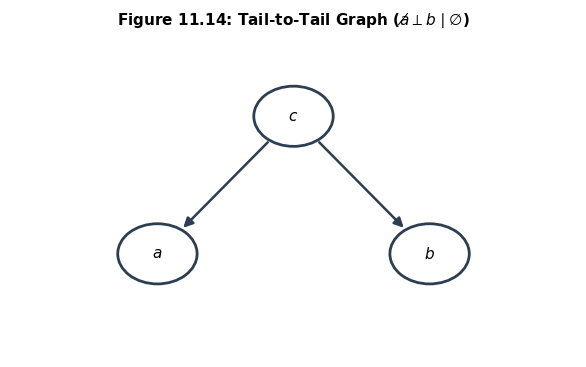

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_15.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_15.png


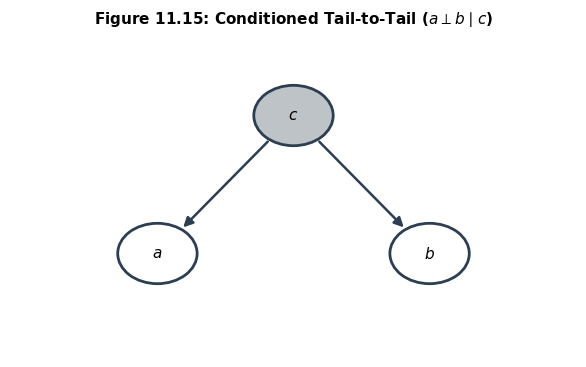

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_16.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_16.png


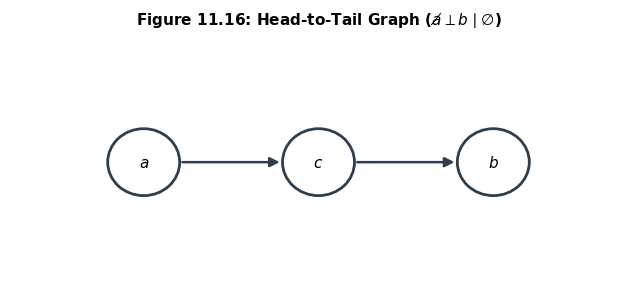

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_17.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_17.png


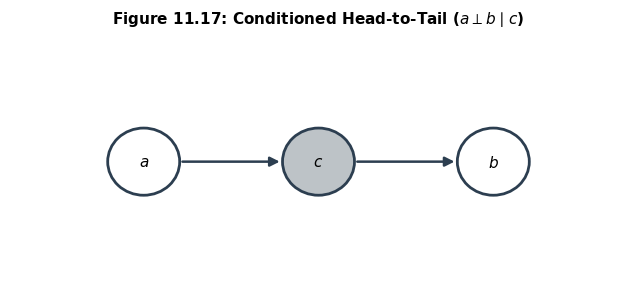

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_18.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_18.png


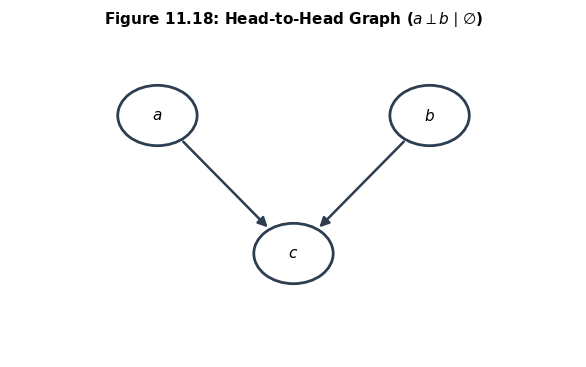

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_19.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_19.png


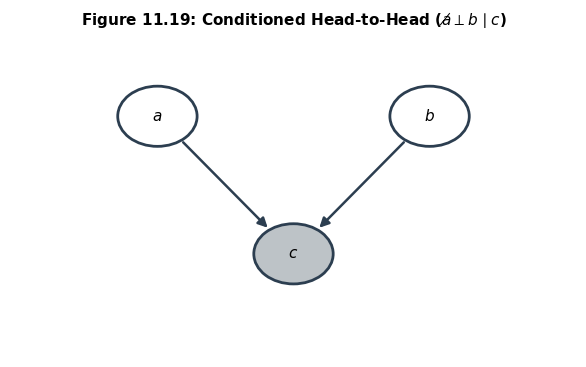

In [2]:
# 図 11.14 & 11.15: テール・トゥ・テール (Tail-to-Tail)
fig_11_14 = generate_figure_11_14()
plt.show()
fig_11_15 = generate_figure_11_15()
plt.show()

# 図 11.16 & 11.17: ヘッド・トゥ・テール (Head-to-Tail)
fig_11_16 = generate_figure_11_16()
plt.show()
fig_11_17 = generate_figure_11_17()
plt.show()

# 図 11.18 & 11.19: ヘッド・トゥ・ヘッド (Head-to-Head / Collider)
fig_11_18 = generate_figure_11_18()
plt.show()
fig_11_19 = generate_figure_11_19()
plt.show()


---
## 11.2.2 説明のつきあい (Explaining Away, 図 11.20, 式 11.32 〜 11.35)

### 車の燃料系における直感的な実例
ヘッド・トゥ・ヘッド構造における「共通の子を観測すると親同士が従属になる」という数学的振る舞いを直感的に理解するための代表例が、教科書で詳述される**車の燃料計システム**です（図 11.20）。

- $B \in \{0, 1\}$: バッテリー状態（$1$: 正常充電, $0$: バッテリー上がり）。事前確率 $p(B=1) = 0.9$。
- $F \in \{0, 1\}$: 燃料タンク状態（$1$: 満タン, $0$: ガス欠・空）。事前確率 $p(F=1) = 0.9$。
- $G \in \{0, 1\}$: 電気式燃料計の指針（$1$: 満タン表示, $0$: 空表示）。

### 確率推論の厳密計算ステップ
1. **事前確率 (Prior, 図 11.20(a))**:
   バッテリーと燃料タンクは物理的に独立に故障するため、$p(B, F) = p(B) p(F)$ であり、$B \perp F \mid \emptyset$。
   タンクが空である事前確率は $p(F = 0) = 0.1$。

2. **燃料計が「空」を示しているのを発見したとき (図 11.20(b))**:
   $G = 0$ が観測された。ベイズの定理より：
   $$
   p(G = 0) = \sum_{B, F} p(G=0 \mid B, F) p(B) p(F) = 0.315 \tag{11.32}
   $$
   $$
   p(G = 0 \mid F = 0) = \sum_B p(G=0 \mid B, F=0) p(B) = 0.81 \tag{11.33}
   $$
   事後確率は：
   $$
   p(F = 0 \mid G = 0) = \frac{p(G=0 \mid F=0) p(F=0)}{p(G=0)} = \frac{0.81 \times 0.1}{0.315} \approx \mathbf{0.257} \tag{11.34}
   $$
   メーターが空を示しているため、ガス欠の確率は事前の $0.1$ から $0.257$ へと跳ね上がります。

3. **さらに「バッテリーも上がっている」ことを発見したとき (図 11.20(c))**:
   $G = 0$ と $B = 0$ の両方を観測。
   $$
   p(F = 0 \mid G = 0, B = 0) = \frac{p(G=0 \mid B=0, F=0) p(F=0)}{\sum_F p(G=0 \mid B=0, F) p(F)} = \frac{0.9 \times 0.1}{0.9 \times 0.1 + 0.8 \times 0.9} = \frac{0.09}{0.81} = \frac{1}{9} \approx \mathbf{0.111} \tag{11.35}
   $$
   **ガス欠の確率は $0.257$ から $0.111$ へと半減（激減）しました！**

### なぜ確率が下がるのか？
メーターが空を示していた原因が「バッテリーが上がっていてメーター自体に通電していなかった」という別の要因によって**十分に説明がついた（Explained Away）**ため、もう一つの候補であった「本当にガス欠である」という仮説の確信度が相対的に低下したのです。
このように、共通の観測効果 $G$ を条件付けることで、独立だった原因 $B$ と $F$ の間に**負の競合関係（負の相関）**が誘導されます。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_20.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_20.png


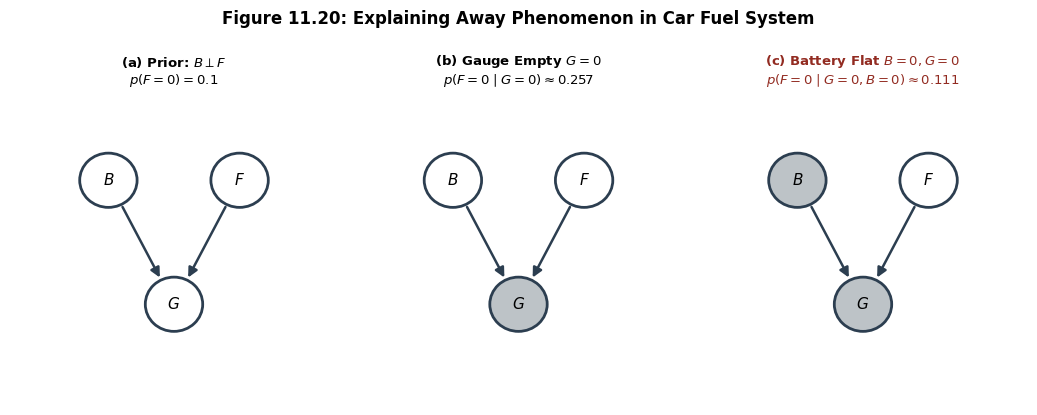

In [3]:
# 図 11.20: 車の燃料系における「説明のつきあい (Explaining Away)」の生成と表示
fig_11_20 = generate_figure_11_20()
plt.show()


---
## 11.2.3 D分離 (D-Separation, 図 11.21, 式 11.36)

### 有向グラフ上のパス遮断ルール
一般の複雑な DAG において、任意の互いに素なノード集合 $A, B$ が、観測ノード集合 $C$ を与えられたときに条件付き独立であるか（$A \perp B \mid C$）を幾何学的に判定する決定的一般規則が **D分離 (Directed Separation / D-Separation)** です。

$A$ 内の任意のノードから $B$ 内の任意のノードへ至るすべての**無向パス（矢印の向きを無視した経路）**を考えます。
パス上のノードが以下のいずれかの条件を満たすとき、そのパスは集合 $C$ によって**遮断（Blocked）**されていると定義されます：
1. そのノードの矢印の出会い方が**ヘッド・トゥ・テール**または**テール・トゥ・テール**であり、そのノードが**条件付け集合 $C$ に含まれている**。
2. そのノードの矢印の出会い方が**ヘッド・トゥ・ヘッド（コライダー）**であり、そのノード自身もその**どの子孫（Descendants）も集合 $C$ に含まれていない**。

$A$ と $B$ を結ぶ**すべてのパスが遮断されている**とき、$A$ と $B$ は $C$ によって **D分離されている**といい、$A \perp B \mid C$ が厳密に成立します。

### i.i.d. データと予測独立性 (式 11.36)
機械学習モデル（図 11.12）において、訓練ターゲット $\{t_n\}$ と新規テスト入力の予測ターゲット $\hat{t}$ の関係を考えます。
$\hat{t}$ から $t_n$ へのパスは、潜在重みノード $\mathbf{w}$ において**テール・トゥ・テール**になっています。
したがって、モデルパラメータ $\mathbf{w}$ を条件付けるとパスは遮断され：
$$
\hat{t} \perp t_n \mid \mathbf{w} \tag{11.36}
$$
が成立します。すなわち、重み $\mathbf{w}$ の事後分布をひとたび学習してしまえば、新規予測を行う際に膨大な過去の訓練データ $\{t_n\}$ を参照し続ける必要はなく、すべてパラメータ $\mathbf{w}$ のみに基づいて予測が可能であるという、機械学習の極めて基本的な性質が D分離から自然に導かれます。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_21.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_21.png


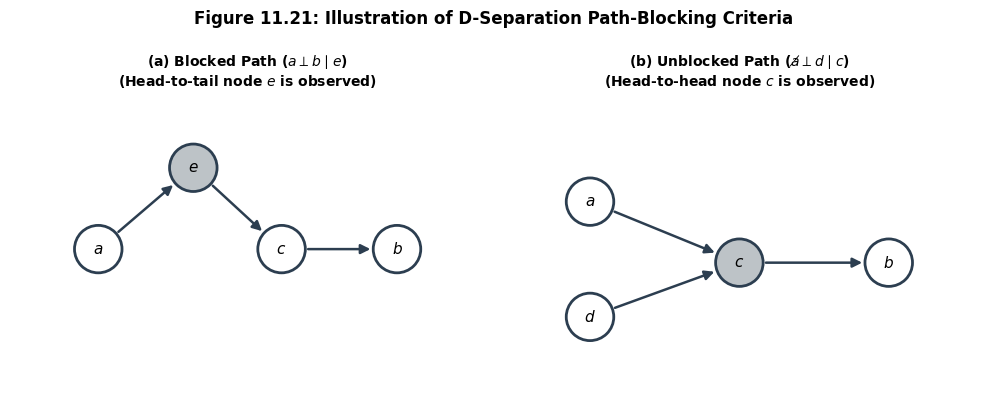

In [4]:
# 図 11.21: D分離の遮断（Blocked）判定基準の可視化
fig_11_21 = generate_figure_11_21()
plt.show()


---
## 11.2.4 ナイーブベイズ & 11.2.5 生成モデル (Naive Bayes & Generative Models)

### ナイーブベイズモデル (図 11.22 & 11.23)
高次元データ $\mathbf{x} = (x^{(1)}, \dots, x^{(L)})$ に対する分類において、クラス $C_k$ が与えられたもとで各特徴量が**互いに独立**であると仮定するモデルです（教科書 式 11.37）：
$$
p(\mathbf{x} \mid C_k) = \prod_{l=1}^L p(x^{(l)} \mid C_k) \tag{11.37}
$$
グラフィカルモデル（図 11.22）で見ると、クラスノード $C_k$ は各特徴量 $x^{(l)}$ に対してテール・トゥ・テールの親となっています。
- $C_k$ を与えると、$x^{(i)}$ と $x^{(j)}$ の間のパスが遮断され、条件付き独立 $x^{(i)} \perp x^{(j)} \mid C_k$ となります。
- しかし、$C_k$ を周辺化するとパスがつながるため、周辺結合分布 $p(\mathbf{x}) = \sum_k p(\mathbf{x} \mid C_k) p(C_k)$ は**因数分解されず、非対角な相関を持つ混合分布**となります（図 11.23）。

### 生成モデルと因果性 (Generative Models, 図 11.24)
画像の物理的生成過程：
- 対象の物体クラス（離散変数）、位置や姿勢・照明（連続変数）がまず独立に選ばれる。
- それらの物理的パラメータが組み合わさって、カメラの受光素子上に最終的な画像ピクセル配列 $\mathbf{X}$ が合成される。
この因果の向き（Causal Direction）に沿ったグラフィカルモデルが**生成モデル**です。
深層学習における識別器（CNN 等）は、画像からクラスや位置を直接予測する「逆問題」を解いていますが、生成過程の独立性構造（照明が変わっても物体の形状は不変である等）を正則化やアーキテクチャ設計に反映させることで、汎化性能を飛躍的に高めることができます。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_22.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_22.png


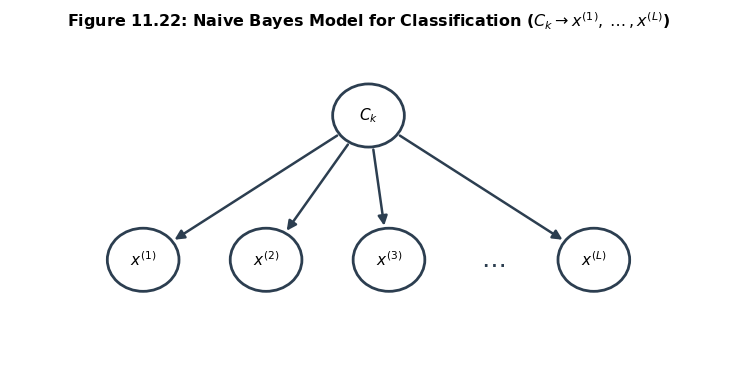

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_23.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_23.png


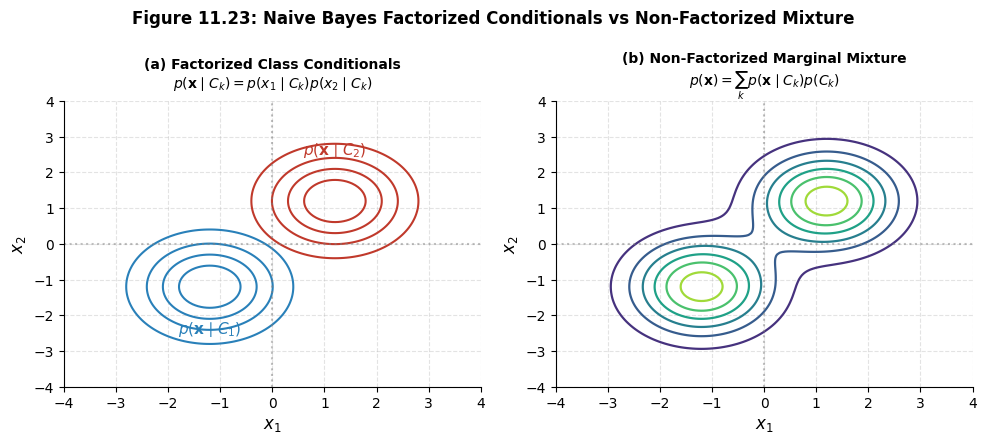

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_24.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_24.png


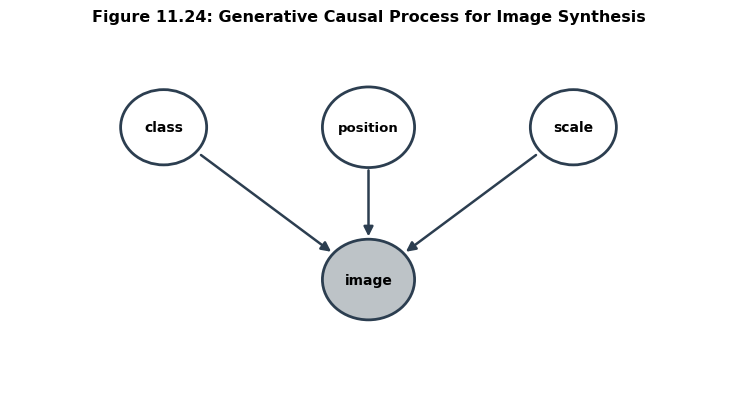

In [5]:
# 図 11.22: ナイーブベイズ分類器のグラフィカルモデル
fig_11_22 = generate_figure_11_22()
plt.show()

# 図 11.23: 2次元ナイーブベイズのクラス条件付き因数分解 vs 周辺混合分布
fig_11_23 = generate_figure_11_23()
plt.show()

# 図 11.24: 画像生成の因果グラフィカルモデル
fig_11_24 = generate_figure_11_24()
plt.show()


---
## 11.2.6 マルコフブランケット & 11.2.7 分布のフィルタとしてのグラフ

### マルコフブランケット (Markov Blanket, 図 11.25)
任意のノード $x_i$ を、グラフ内の残りのすべてのノード $\mathbf{x}_{\setminus i}$ から完全に条件付き独立にする最小のノード集合を **マルコフブランケット $\mathrm{MB}(x_i)$** と呼びます：
$$
p(x_i \mid \mathbf{x}_{\setminus i}) = p(x_i \mid \mathrm{MB}(x_i))
$$
有向グラフにおいて、マルコフブランケットは以下の3種類のノードの和集合で過不足なく構成されます：
1. **親ノード群 (Parents)**: $x_i$ に直接入ってくるノード。
2. **子ノード群 (Children)**: $x_i$ から直接出ていくノード。
3. **共通親ノード群 (Co-parents)**: $x_i$ の子ノード群の「もう一方の親」ノード群。
※コライダー構造において、子ノードが観測されるともう一方の親（co-parents）が $x_i$ と従属になってしまうため、遮断するためには co-parents も必ずマルコフブランケットに含める必要があります。

### 分布のフィルタとしてのグラフ (Graphs as Filters, 図 11.26)
グラフィカルモデル $G$ は、あらゆる確率分布の巨大な集合 $\mathcal{P}$ に対する**フィルタ**として捉えることができます。
1. **因数分解可能な分布族 $\mathcal{DF}$**: グラフ $G$ のリンク構造に従って $p(\mathbf{x}) = \prod_k p(x_k \mid \mathrm{pa}_k)$ と因数分解できる分布の集合。これらは $G$ に示されたすべての条件付き独立性を必ず満たす。
2. **不忠実な分布 (Unfaithful Distributions, $\mathcal{UI}$)**: パラメータの特殊な数値的一致（例：パス間の効果が偶然完全に打ち消し合う場合）により、グラフのトポロジーには示されていない追加の独立性を偶然満たしてしまう特殊な分布。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_25.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_25.png


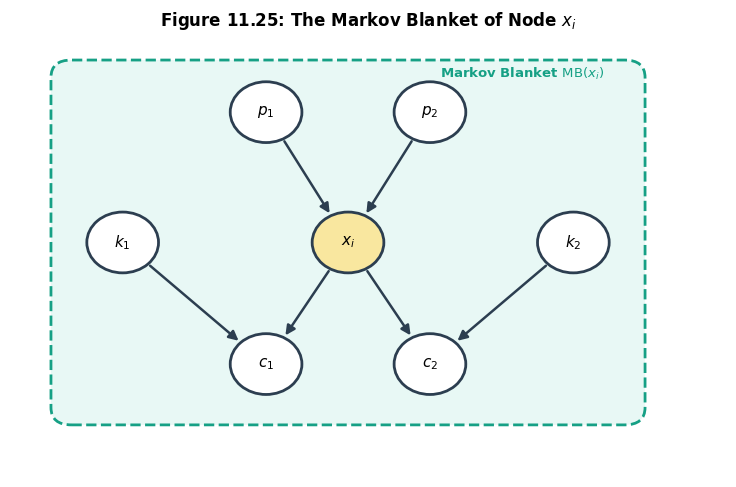

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/11/result/Figure_11_26.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/Figure_11_26.png


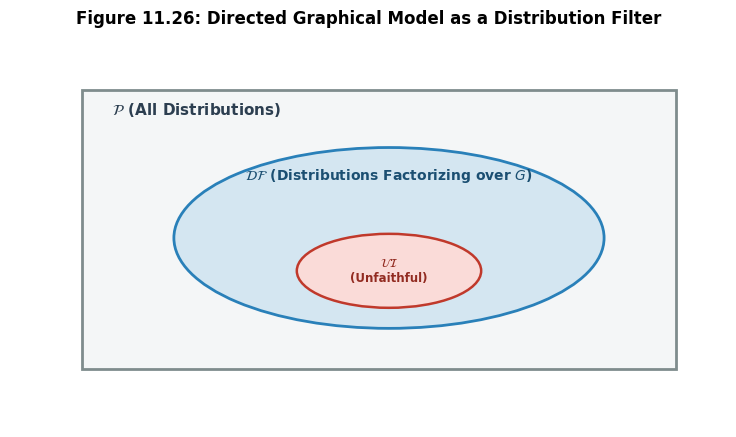

In [6]:
# 図 11.25: ノード x_i のマルコフブランケット (親・子・共通親)
fig_11_25 = generate_figure_11_25()
plt.show()

# 図 11.26: 分布のフィルタとしての有向グラフィカルモデル
fig_11_26 = generate_figure_11_26()
plt.show()


---
## 9. 数値検証セル (Numerical Verification)

共通モジュール `common/conditional_independence.py` の定式化について、以下の数学的・統計的性質を厳密に検証します：
1. **3大基本構造の D分離動作**:
   - テール・トゥ・テール：未観測で従属、観測で独立。
   - ヘッド・トゥ・テール：未観測で従属、観測で独立。
   - ヘッド・トゥ・ヘッド：未観測で独立、観測で従属。
2. **説明のつきあい (Explaining Away) の完全再現 (式 11.32 〜 11.35)**:
   - 周辺確率 $p(G=0) = 0.315$。
   - 条件付き確率 $p(G=0 \mid F=0) = 0.81$。
   - 事後確率 $p(F=0 \mid G=0) \approx 0.257$。
   - 二重観測事後確率 $p(F=0 \mid G=0, B=0) = 1/9 \approx 0.111$。
3. **マルコフブランケットの遮断性**:
   - $\mathrm{MB}(x_i)$ を条件付けると、残りの全ノードと D分離されることの確認。


In [7]:
# 1. 3大基本構造のD分離検証
dag_ttt = DirectedGraph(["a", "b", "c"])
dag_ttt.add_edge("c", "a")
dag_ttt.add_edge("c", "b")
assert not check_d_separation(dag_ttt, {"a"}, {"b"}, set())
assert check_d_separation(dag_ttt, {"a"}, {"b"}, {"c"})

dag_hth = DirectedGraph(["a", "b", "c"])
dag_hth.add_edge("a", "c")
dag_hth.add_edge("b", "c")
assert check_d_separation(dag_hth, {"a"}, {"b"}, set())
assert not check_d_separation(dag_hth, {"a"}, {"b"}, {"c"})
print("✓ Three canonical 3-node graph d-separation verified.")

# 2. 車の燃料系 (Explaining Away) の完全数値検証
car = CarFuelSystem()
assert np.isclose(car.compute_marginal_p_G0(), 0.315)
assert np.isclose(car.compute_conditional_p_G0_given_F0(), 0.81)
assert np.isclose(car.compute_posterior_p_F0_given_G0(), 0.081 / 0.315)
assert np.isclose(car.compute_posterior_p_F0_given_G0_B0(), 1.0 / 9.0)

print(f"✓ Explaining Away verified: p(F=0|G=0) = {car.compute_posterior_p_F0_given_G0():.3f} -> p(F=0|G=0,B=0) = {car.compute_posterior_p_F0_given_G0_B0():.3f}")

# 3. マルコフブランケットのD分離完全性
dag_mb = DirectedGraph(["xi", "p1", "p2", "c1", "c2", "k1", "k2", "remote"])
dag_mb.add_edge("p1", "xi")
dag_mb.add_edge("p2", "xi")
dag_mb.add_edge("xi", "c1")
dag_mb.add_edge("xi", "c2")
dag_mb.add_edge("k1", "c1")
dag_mb.add_edge("k2", "c2")
dag_mb.add_edge("remote", "p1")

mb = get_markov_blanket(dag_mb, "xi")
assert mb == {"p1", "p2", "c1", "c2", "k1", "k2"}
assert check_d_separation(dag_mb, {"xi"}, {"remote"}, mb)
print("✓ Markov blanket d-separation condition verified.")


✓ Three canonical 3-node graph d-separation verified.
✓ Explaining Away verified: p(F=0|G=0) = 0.257 -> p(F=0|G=0,B=0) = 0.111
✓ Markov blanket d-separation condition verified.


---
## 10. まとめと次節 11.3（系列モデル）への展開

### 本節で学んだ最重要概念
1. **3つの基本接続パターン**:
   - テール・トゥ・テールおよびヘッド・トゥ・テールは観測によってパスが遮断される。
   - ヘッド・トゥ・ヘッド（コライダー）は逆に観測によってパスが開通する。
2. **説明のつきあい (Explaining Away)**:
   - 共通の観測効果を条件付けることで、独立だった競合する原因の間に負の相関が誘導される。
3. **D分離**:
   - グラフの接続構造を調べるだけで、代数計算を一切行わずに大域的条件付き独立性を判定できる。
4. **マルコフブランケット**:
   - 親、子、共通親で構成され、ノードをグラフの残りすべてから完全に隔離する。
5. **ナイーブベイズと因果生成モデル**:
   - 強い条件付き独立性仮定により、高次元特徴空間の密度推定を1次元の積に単純化。

### 次節 11.3 系列モデル (Sequence Models) への展開
グラフィカルモデルの概念は、時間的に連続するデータや言語・テキストのような系列データのモデリングにおいて決定的な役割を果たします。
次節 **11.3 Sequence Models** では、自己回帰モデル（Autoregressive Models）、第1次マルコフ連鎖、第2次マルコフ連鎖、そして観測不可能な潜在状態の推移を通じて長期記憶を表現する **状態空間モデル (State-Space Models)** や隠れマルコフモデル（HMM）のグラフィカルモデル表現と、その条件付き独立性構造（図 11.27 〜 11.31）を学びます。
